In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 모델링
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgbm
from catboost import CatBoostRegressor

# 평가지표
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 파이프라인
from sklearn.pipeline import Pipeline

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)
random_seed = 42

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
os.chdir(os.path.abspath('..'))
print(os.getcwd())

c:\workspace\camp\project\airbnb_price_prediction


In [3]:
# 이 경로에서 원하는 데이터로 변경
def load_borough_data(base_path, borough_name):
    """
    특정 자치구 폴더에서 6개의 CSV 파일을 로드하여 반환합니다.
    """
    
    if borough_name == 'manhattan':
        suffix = 'mnh'
    elif borough_name == 'brooklyn':
        suffix = 'bkl'
    else:
        suffix = borough_name

    path = f'{base_path}/{borough_name}'
    
    X_train = pd.read_csv(f'{path}/X_train_{suffix}.csv')
    y_train = pd.read_csv(f'{path}/y_train_{suffix}.csv').squeeze()
    X_test = pd.read_csv(f'{path}/X_test_{suffix}.csv')
    y_test = pd.read_csv(f'{path}/y_test_{suffix}.csv').squeeze()
    ids_train = pd.read_csv(f'{path}/ids_train_{suffix}.csv')
    ids_test = pd.read_csv(f'{path}/ids_test_{suffix}.csv')
    
    return X_train, y_train, X_test, y_test, ids_train, ids_test

base = 'data'

# 보고 싶은 파트를 바꾸면 됨!
X_train, y_train, X_test, y_test, ids_train, ids_test = load_borough_data(base, 'all')

In [4]:
xgb_reg = xgb.XGBRegressor(
    random_state = random_seed,
    n_jobs = -1,
    verbosity = 1,
    tree_method = 'hist'
)

# 우리는 요정도만! 설정해볼까요? + 처음에 n_estimators를 작게하고 다른 것들을 좁혀나가다가, n_estimators를 늘려가는 식으로가 팁!
# 우선 100 ~ 300으로 하다가, 어느 정도 된 거 같으면 n_estimator 늘려보기
# 다중공선성 체크 안 하고 변수 다 때려넣었으니, L1 규제(유의미하지 않으면 0으로 만드는 규제) 사용해보기
# 과적합 우려가 높기 때문에, min_child_weight 사용해보기
param_grid = {
    'n_estimators' : [900,1000,1100],
    'max_depth' : [7],
    'learning_rate' : [0.03],
    'subsample' : [0.9],
    'colsample_bytree' : [0.8],
    'min_child_weight' : [5,6],
    'alpha' : [0.1],
}

# model_cv = GridSearchCV(
#     estimator = xgb_reg,
#     param_grid = param_grid,
#     scoring = 'neg_mean_squared_error',
#     cv = 5,
#     n_jobs = -1,
#     verbose = 2,
#     return_train_score = True
# )

model_cv = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_grid, 
    n_iter=100,                     
    scoring='neg_mean_squared_error',
    cv=3,                          
    n_jobs=-1,
    verbose=3,
    return_train_score = True,
    random_state=random_seed,
)

model_cv.fit(X_train, y_train)
print(f'최적 파라미터 : {model_cv.best_params_}')
print(f'최적 RMSE : {model_cv.best_score_}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
최적 파라미터 : {'subsample': 0.9, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.8, 'alpha': 0.1}
최적 RMSE : -0.09726105418572846


In [5]:
cv_df = pd.DataFrame(model_cv.cv_results_)[
    ["param_n_estimators", "param_max_depth","param_learning_rate",'param_subsample', 'param_colsample_bytree',
    'param_subsample','param_min_child_weight', 'param_alpha',
    "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]
].rename(columns={
    "param_n_estimators" : "n_estimators",
    "param_max_depth": "max_depth",
    "param_learning_rate" : 'learning_rate',
    "param_subsample" : "subsample",
    "param_colsample_bytree" : "colsample_bytree",
    "mean_train_score": "훈련 정확도",
    "mean_test_score": "검증 정확도",
    "std_test_score": "표준편차",
    "rank_test_score": "순위",
}).sort_values("순위")

cv_df.head(15)

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,subsample,param_min_child_weight,param_alpha,훈련 정확도,검증 정확도,표준편차,순위
1,1000,7,0.03,0.9,0.8,0.9,5,0.1,-0.005587,-0.097261,0.001802,1
2,1100,7,0.03,0.9,0.8,0.9,5,0.1,-0.004362,-0.097265,0.001738,2
0,900,7,0.03,0.9,0.8,0.9,5,0.1,-0.007157,-0.097345,0.001743,3
4,1000,7,0.03,0.9,0.8,0.9,6,0.1,-0.005929,-0.097793,0.002172,4
3,900,7,0.03,0.9,0.8,0.9,6,0.1,-0.007571,-0.097805,0.002183,5
5,1100,7,0.03,0.9,0.8,0.9,6,0.1,-0.004669,-0.097825,0.002206,6


In [6]:
best_model = model_cv.best_estimator_
pred_final = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_final))
rmse2 = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_final)))

r2 = r2_score(y_test, pred_final)
# r2 = r2_score(np.expm1(y_test), np.expm1(pred_final))
mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(pred_final))
# mape = mean_absolute_percentage_error(y_test, pred_final)

print(f"교차검증 RMSE: {model_cv.best_score_:.3f}")
print(f"Log Root Mean Squared Error: {rmse:.3f}")
print(f"결정 계수 : {r2 * 100:.3f}%")
print()

print(f'원래 가격의 RMSE : {rmse2:.3f}')
print(f'원래 가격의 MAPE : {mape * 100:.3f}%')

교차검증 RMSE: -0.097
Log Root Mean Squared Error: 0.309
결정 계수 : 76.489%

원래 가격의 RMSE : 64.488
원래 가격의 MAPE : 24.018%


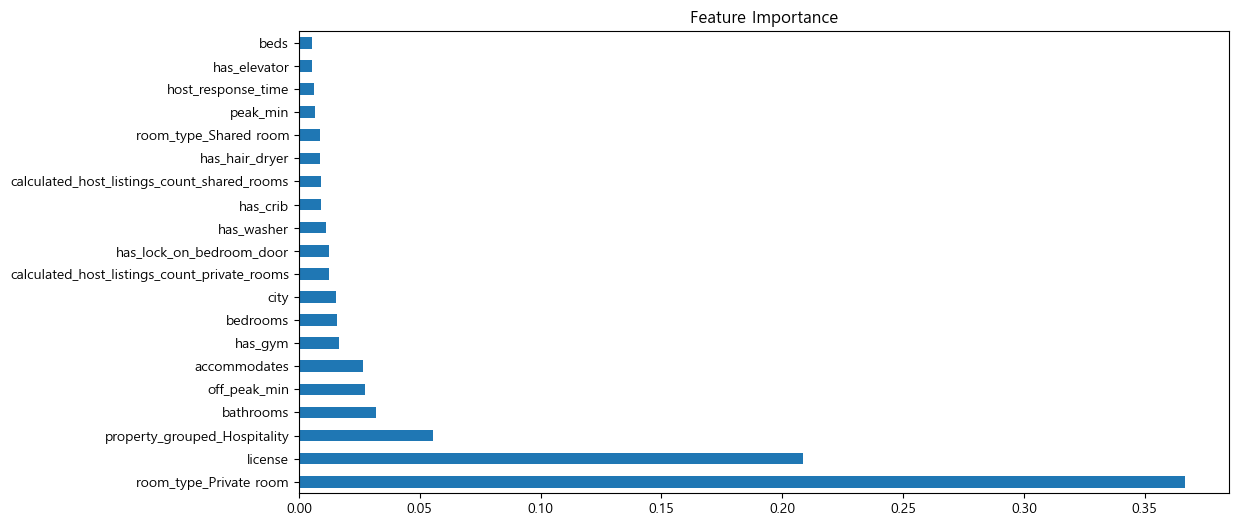

In [7]:
# 최적의 모델에서 피처 중요도 뽑기
import matplotlib.pyplot as plt

best_model = model_cv.best_estimator_
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title("Feature Importance")
plt.show()

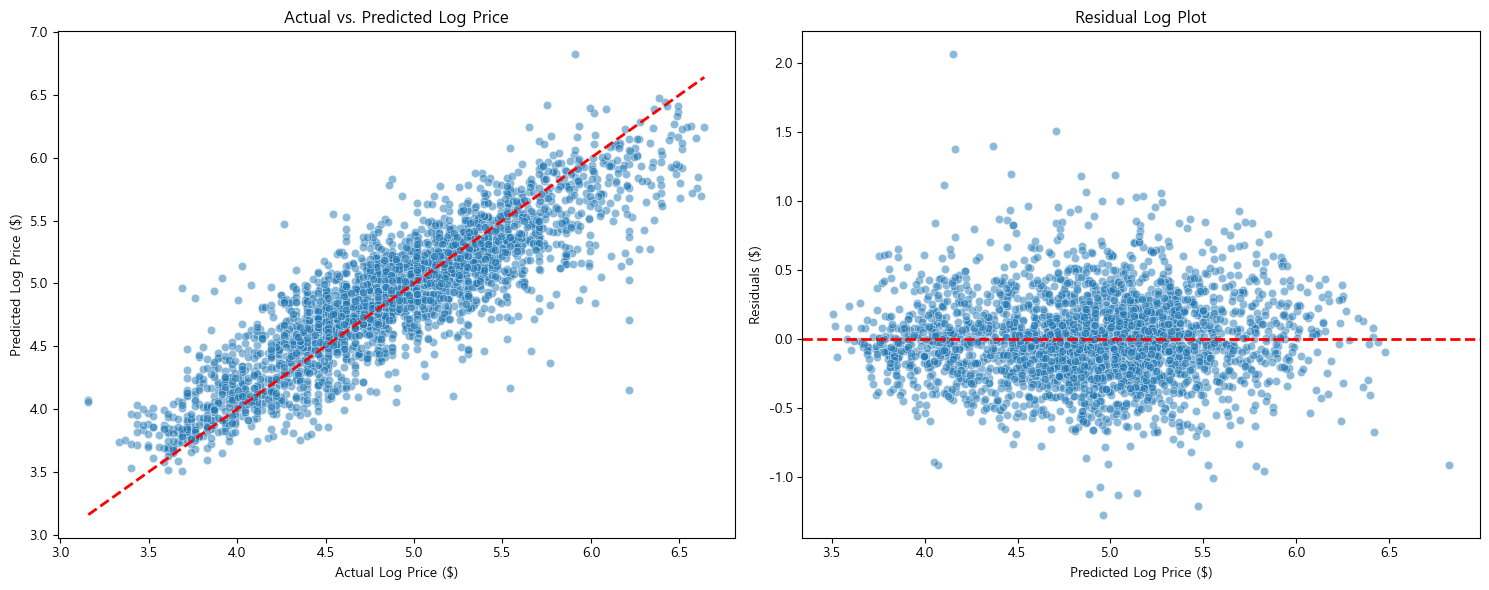

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (로그 단위를 원본 달러 단위로 복원)
y_test_orig = y_test
y_pred_orig = pred_final
residuals = y_test_orig - y_pred_orig

# 시각화 설정
plt.figure(figsize=(15, 6))

# 그래프 1: 실제값 vs 예측값 (Actual vs Predicted)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Log Price ($)')
plt.ylabel('Predicted Log Price ($)')
plt.title('Actual vs. Predicted Log Price')

# 그래프 2: 잔차도 (Residual Plot)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_orig, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Log Price ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Log Plot')

plt.tight_layout()
plt.show()

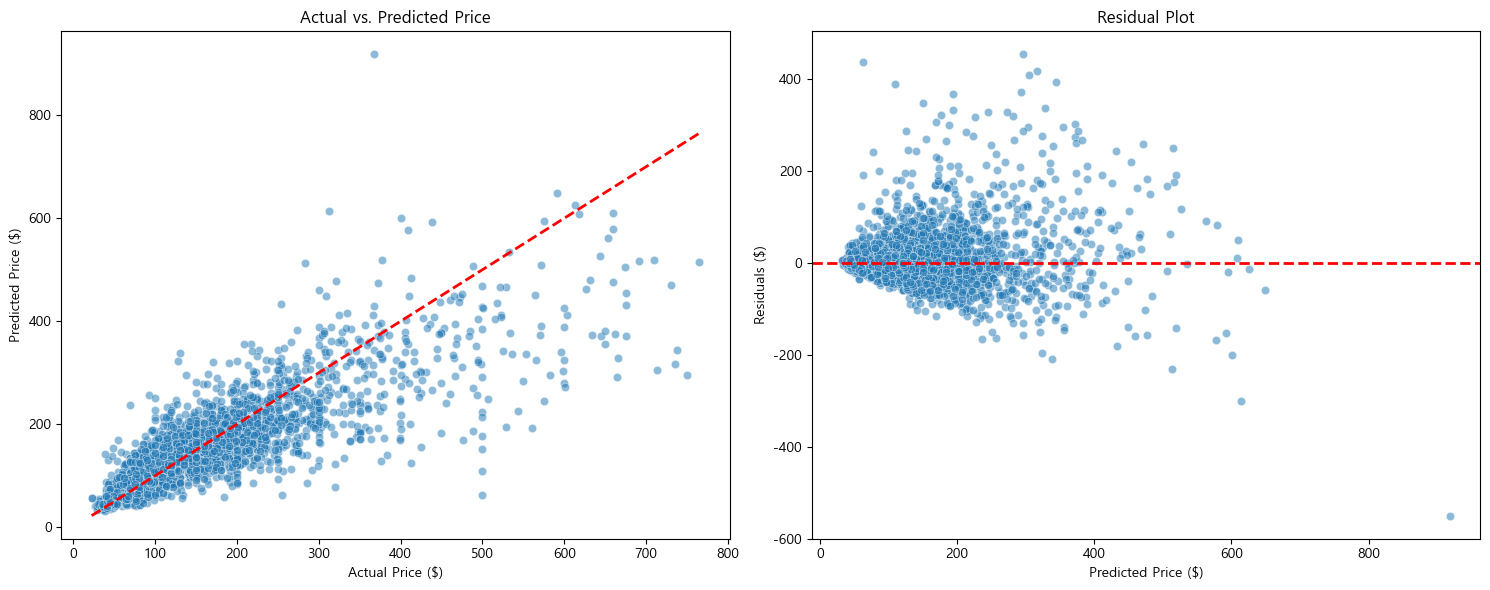

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (로그 단위를 원본 달러 단위로 복원)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(pred_final)
residuals = y_test_orig - y_pred_orig

# 시각화 설정
plt.figure(figsize=(15, 6))

# 그래프 1: 실제값 vs 예측값 (Actual vs Predicted)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs. Predicted Price')

# 그래프 2: 잔차도 (Residual Plot)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_orig, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

In [11]:
best_model.get_booster().save_model('results/xgb_model_all.json') # -> 여기 저장하고 싶은 이름으로 바꾸기!

- 같은 방식으로 전체 데이터, 맨해튼, 브루클린, other에 대해 모델링 진행

In [12]:
all_model = xgb.XGBRegressor() # 객체 먼저 생성
all_model.load_model('results/xgb_model_all.json')

In [ ]:
import shap
explainer = shap.TreeExplainer(all_model)

In [15]:
shap_values = explainer.shap_values(X_test)

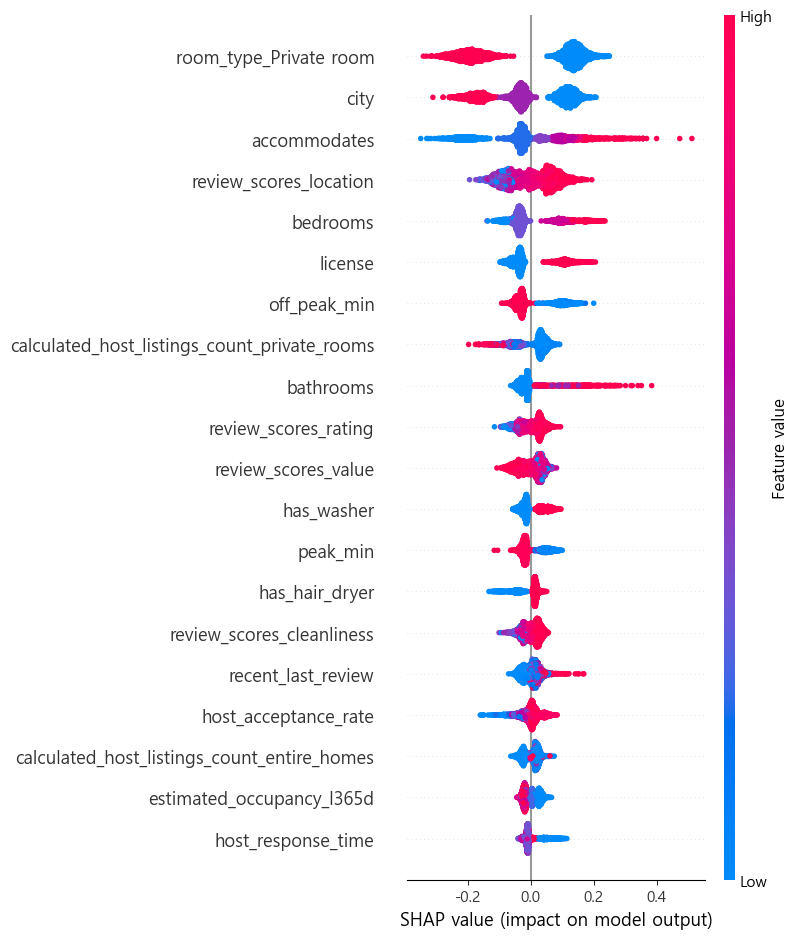

In [16]:
feature_names = X_test.columns

# 각 변수 별 생존에 대한 기여도 확인
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

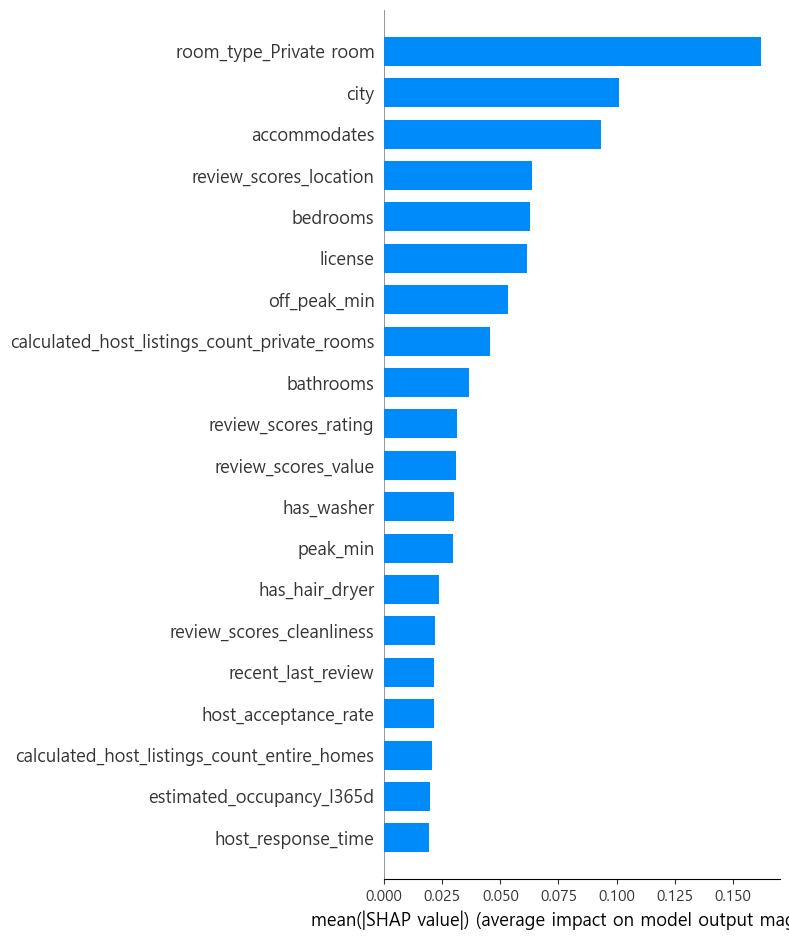

In [17]:
shap.summary_plot(shap_values, X_test, feature_names = feature_names, plot_type = 'bar')

In [ ]:
base_value = explainer.expected_value

np.float32(4.8907876)

array([4.5016685, 5.6623373, 5.3061934, ..., 5.109728 , 5.6157146,
       4.126245 ], shape=(2913,), dtype=float32)

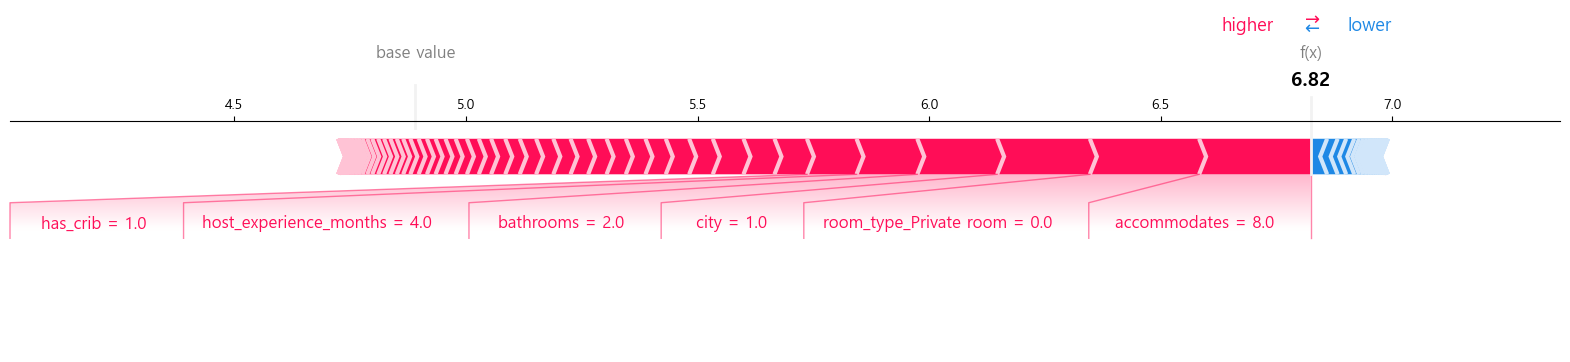

In [53]:
base_value = explainer.expected_value
# 첫 번째 승객 기여도(shap_value)
passenger_shap = shap_values[1358]
# 첫 번째 승객 실제 데이터
passenger_data = X_test.loc[1358,:]
shap.force_plot(
    base_value, 
    passenger_shap, 
    passenger_data, 
    feature_names=feature_names,
    matplotlib=True # 주피터 노트북에서 바로 보려면 필수!
)

In [ ]:
np.expm1(pred_final) > 800

array([ 89.16744 , 286.8206  , 200.58142 , ..., 164.62527 , 273.7096  ,
        60.944885], shape=(2913,), dtype=float32)

In [52]:
tmp_df.loc[np.expm1(tmp_df['predict_value']) > 800,'index']

1358    1358
Name: index, dtype: int64

array([6.82349], dtype=float32)

In [55]:
xgb.__version__

'3.0.3'